In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
df = pd.read_csv("smartcart_customers.csv")

In [3]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [4]:
df.shape

(2240, 22)

In [5]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

# Data preprocessing

In [6]:
# Handle Missing Values

df["Income"]=df["Income"].fillna(df["Income"].median())

In [7]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [8]:
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
dtype: int64

In [9]:
# Feature Engineering 
# add age

df["Age"]= 2026-df["Year_Birth"]

In [10]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,88,88,3,8,10,4,7,0,1,69
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,1,6,2,1,1,2,5,0,0,72
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,21,42,1,8,2,10,4,0,0,61
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,3,5,2,2,0,4,6,0,0,42
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,27,15,5,5,3,6,5,0,0,45


In [11]:
# Customer Joining Days

df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst=True)

refrence_date=df["Dt_Customer"].max()

df["Customer_Tenure_Days"] = (refrence_date-df["Dt_Customer"]).dt.days

In [12]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,88,3,8,10,4,7,0,1,69,663
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,6,2,1,1,2,5,0,0,72,113
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,42,1,8,2,10,4,0,0,61,312
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,5,2,2,0,4,6,0,0,42,139
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,15,5,5,3,6,5,0,0,45,161


In [13]:
# Add Total spending

df["Total_Spending"] = df["MntWines"] + df["MntFruits"] + df["MntMeatProducts"] + df["MntFishProducts"] + df["MntSweetProducts"] + df["MntGoldProds"]

In [14]:
# total children 

df["Children"] = df["Kidhome"] + df["Teenhome"] 

In [15]:
# Education

df["Education"].value_counts()

df["Education"] = df["Education"].replace({
    "Basic":"Undergraduate", "2n Cycle": "Undergraduate",
    "Graduation": "Graduate",
    "Master": "Postgraduate", "PhD": "Postgraduate"
})

In [66]:
# Marital Status
df["Marital_Status"].value_counts()

df["Marital_Status"] = df["Marital_Status"].replace({
    "Married":"Partner", "Together": "Partner",
    "Single": "Alone", "Divorced":"Alone",
    "Widow":"Alone", "YOLO":"Alone", "Absurd":"Alone"
})
    

In [67]:
df["Marital_Status"].value_counts()

Marital_Status
Partner    1444
Alone       796
Name: count, dtype: int64

# Drop Columns

In [68]:
cols = ["ID", "Year_Birth", "Marital_Status", "Kidhome", "Teenhome", "Dt_Customer"]
spending_cols = ["MntWines", "MntWines", "MntMeatProducts", "MntFishProducts","MntSweetProducts", "MntGoldProds"]

cols_to_drop = cols+spending_cols
df_cleaned = df.drop(columns=cols_to_drop)

In [69]:
df_cleaned.shape

(2240, 16)

In [70]:
df_cleaned.head()

,Education,Income,Recency,MntFruits,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Children,Living_With
0,Graduate,58138.0,58,88,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,1,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,49,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduate,26646.0,26,4,2,2,0,4,6,0,0,42,139,53,1,Partner
4,Postgraduate,58293.0,94,43,5,5,3,6,5,0,0,45,161,422,1,Partner


# Outliers

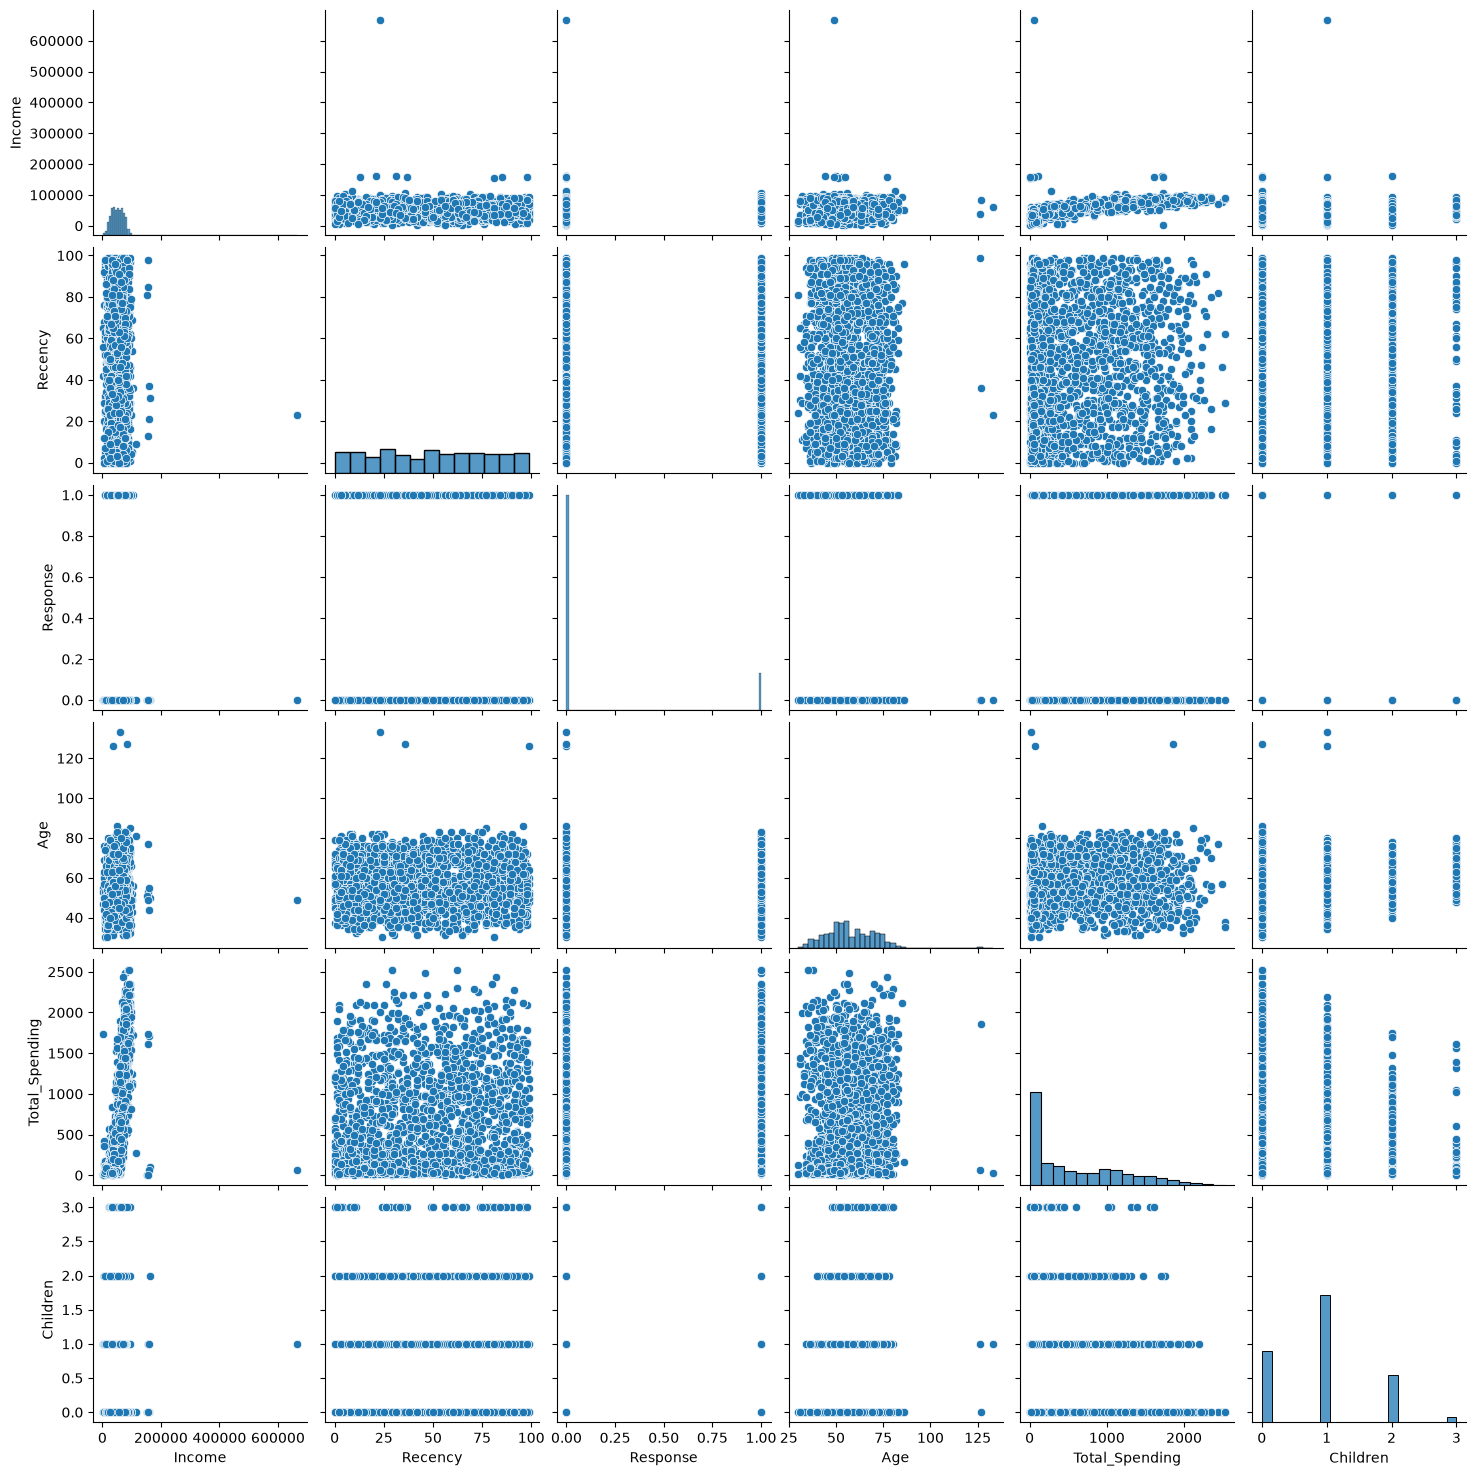

In [71]:
cols = ["Income", "Recency", "Response", "Age", "Total_Spending", "Children"]
# relative plots of some features pair plos
sns.pairplot(df_cleaned[cols])

In [72]:
# Remove Outliers

print("data size with outliers", len(df_cleaned))
df_cleaned = df_cleaned[(df_cleaned["Age"]<90)]
df_cleaned = df_cleaned[(df_cleaned["Income"] <600_000)]

print("data size without outliers" , len(df_cleaned))

data size with outliers 2240
data size without outliers 2236


# HeatMap

In [73]:
corr = df_cleaned.corr(numeric_only=True)

<Axes: >

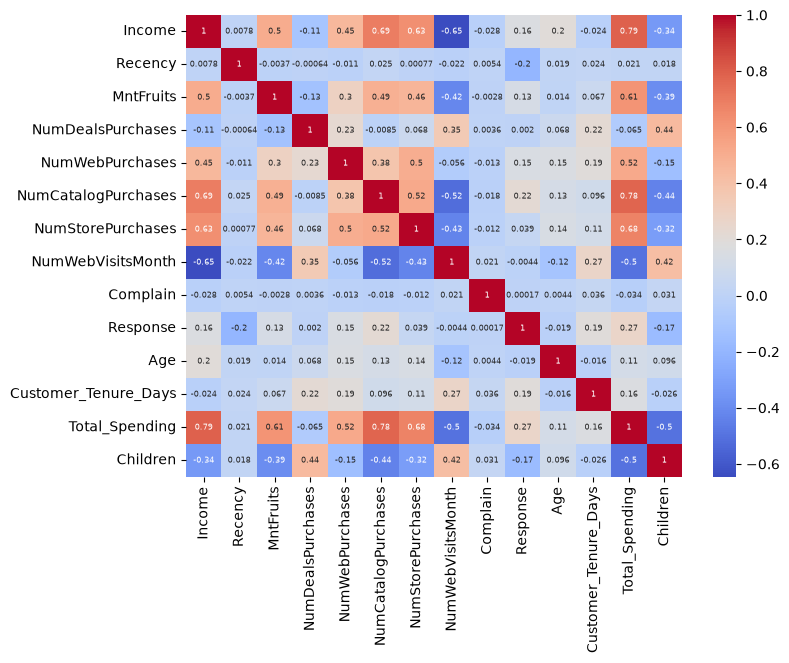

In [74]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    annot_kws={"size":6},
    cmap="coolwarm"
)
    

In [75]:
df_cleaned.shape

(2236, 16)

In [76]:
df_cleaned.head()

,Education,Income,Recency,MntFruits,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Children,Living_With
0,Graduate,58138.0,58,88,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,1,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,49,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduate,26646.0,26,4,2,2,0,4,6,0,0,42,139,53,1,Partner
4,Postgraduate,58293.0,94,43,5,5,3,6,5,0,0,45,161,422,1,Partner


# Encoding

In [77]:
from sklearn.preprocessing import OneHotEncoder

In [79]:
ohe = OneHotEncoder()

cat_cols = ["Education", "Living_With"]

enc_cols = ohe.fit_transform(df_cleaned[cat_cols])

In [80]:
enc_df = pd.DataFrame(enc_cols.toarray(), columns=ohe.get_feature_names_out(cat_cols), index=df_cleaned.index)

In [81]:
enc_df

,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
0,1.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,1.0
4,0.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...
2235,1.0,0.0,0.0,0.0,1.0
2236,0.0,1.0,0.0,0.0,1.0
2237,1.0,0.0,0.0,1.0,0.0
2238,0.0,1.0,0.0,0.0,1.0


In [83]:
df_encoded = pd.concat([df_cleaned.drop(columns=cat_cols),enc_df], axis = 1)

In [84]:
df_encoded

,Income,Recency,MntFruits,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
0,58138.0,58,88,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,1,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,49,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,4,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,43,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,61223.0,46,43,2,9,3,4,5,0,0,59,381,1341,1,1.0,0.0,0.0,0.0,1.0
2236,64014.0,56,0,7,8,2,5,7,0,0,80,19,444,3,0.0,1.0,0.0,0.0,1.0
2237,56981.0,91,48,1,2,3,13,6,0,0,45,155,1241,0,1.0,0.0,0.0,1.0,0.0
2238,69245.0,8,30,2,6,5,10,3,0,0,70,156,843,1,0.0,1.0,0.0,0.0,1.0


# Scaling & Visualize

In [86]:
from sklearn.preprocessing import StandardScaler

In [87]:
X = df_encoded

In [88]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [89]:
X_scaled.shape

(2236, 19)

In [94]:
# 2D

from sklearn.decomposition import PCA

pca = PCA(n_components = 3)

X_pca = pca.fit_transform(X_scaled)

In [95]:
pca.explained_variance_ratio_

array([0.24149181, 0.10787339, 0.1003017 ])

Text(0.5, 0.92, '3d-Projection')

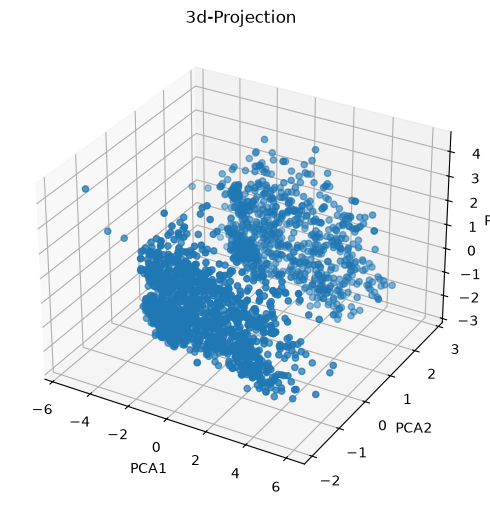

In [98]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X_pca[:,0], X_pca[:,1],X_pca[:,2])
ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3d-Projection")

# Analyze K value
## 1. Elbow Method

In [99]:
from sklearn.cluster import KMeans
from kneed import KneeLocator 

wcss =[]
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)


In [101]:
knee = KneeLocator(range(1,11), wcss, curve="convex", direction = "decreasing")
optimal_k = knee.elbow

In [102]:
print("best k =", optimal_k)

best k = 4


Text(0, 0.5, 'WCSS')

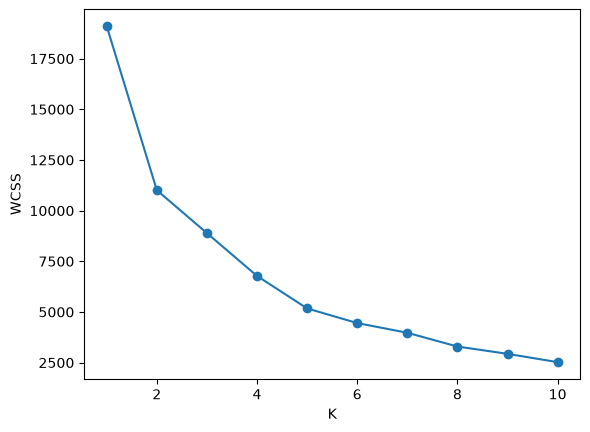

In [103]:
plt.plot(range(1,11),wcss, marker="o")
plt.xlabel("K")
plt.ylabel("WCSS")

## 2. Silhouette Score

Text(0, 0.5, 'Silhouette score')

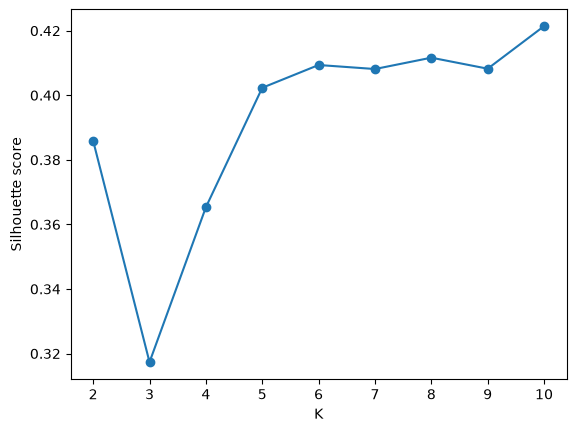

In [105]:
from sklearn.metrics import silhouette_score

scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters = k, random_state=42)
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    scores.append(score)

# plot
plt.plot(range(2,11), scores, marker="o")
plt.xlabel("K")
plt.ylabel("Silhouette score")

Text(0, 0.5, 'SS')

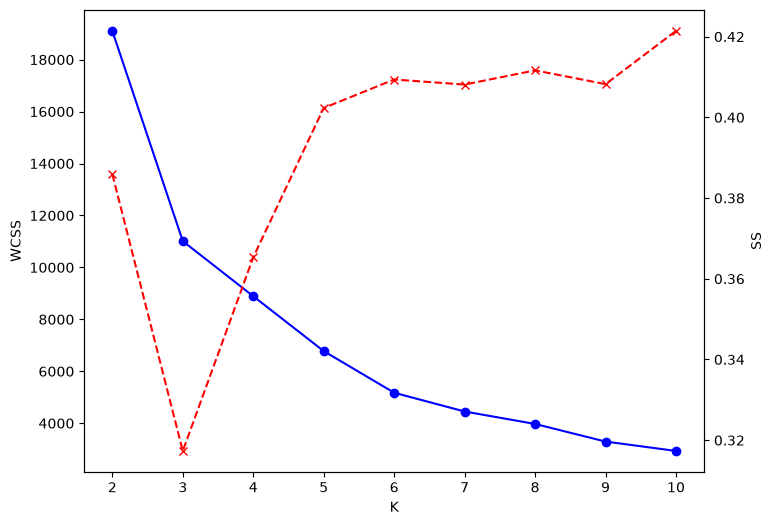

In [107]:
# combined plot

k_range = range(2,11)

fig, ax1 = plt.subplots(figsize=(8,6))

ax1.plot(k_range, wcss[:len(k_range)], marker="o", color="blue")
ax1.set_xlabel("K")
ax1.set_ylabel("WCSS")

ax2 = ax1.twinx()
ax2.plot(k_range, scores[:len(k_range)], marker="x", color="red", linestyle = "--")

ax2.set_ylabel("SS")

# Clustering Algorithm

In [108]:
# K Means algo 

kmeans = KMeans(n_clusters = 4, random_state=42)
labels_kmeans = kmeans.fit_predict(X_pca)

Text(0.5, 0.92, '3d-Projection')

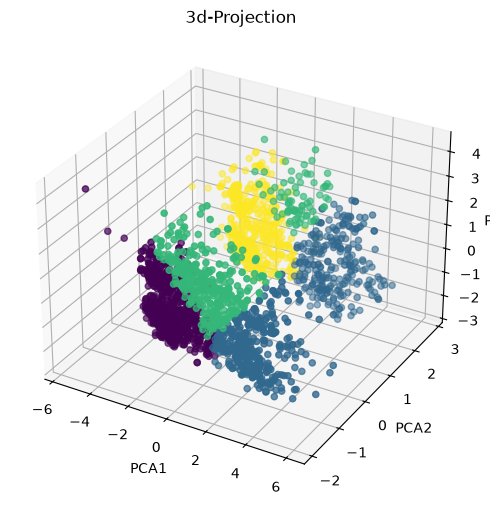

In [112]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X_pca[:,0], X_pca[:,1],X_pca[:,2], c=labels_kmeans)
ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3d-Projection")

In [111]:
# Agglomerative Clustering 

from sklearn.cluster import AgglomerativeClustering
agg_clf = AgglomerativeClustering(n_clusters=4, linkage="ward")
labels_agg = agg_clf.fit_predict(X_pca)

Text(0.5, 0.92, '3d-Projection')

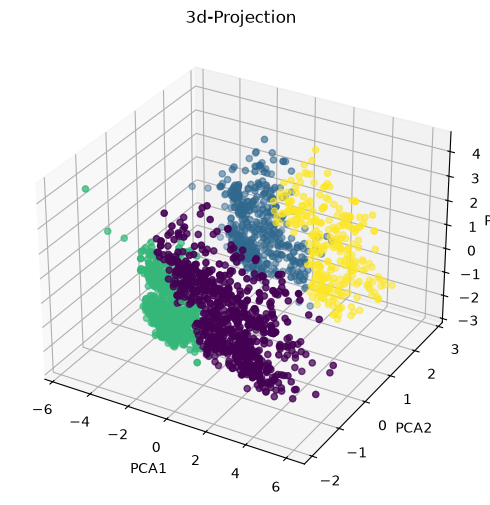

In [113]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X_pca[:,0], X_pca[:,1],X_pca[:,2], c=labels_agg)
ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3d-Projection")

# Characterization of Clusters

In [125]:

X["clusters"] = labels_agg
X.head()

,Income,Recency,MntFruits,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner,clusters
0,58138.0,58,88,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0,3
1,46344.0,38,1,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0,1
2,71613.0,26,49,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0,0
3,26646.0,26,4,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0,2
4,58293.0,94,43,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0,0


<Axes: xlabel='clusters', ylabel='count'>

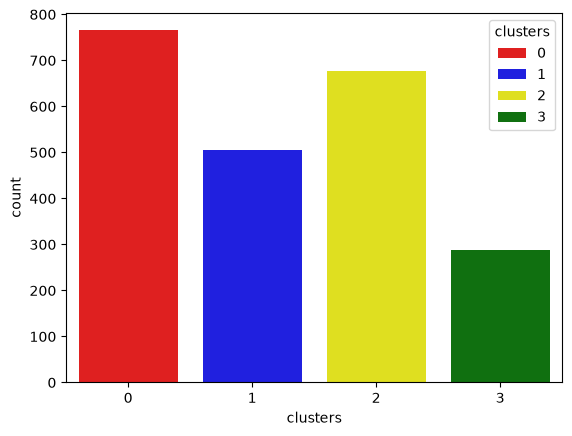

In [127]:
pal = ["red", "blue", "yellow", "green"]
sns.countplot(x=X["clusters"], palette=pal, hue=X["clusters"])

<Axes: xlabel='Total_Spending', ylabel='Income'>

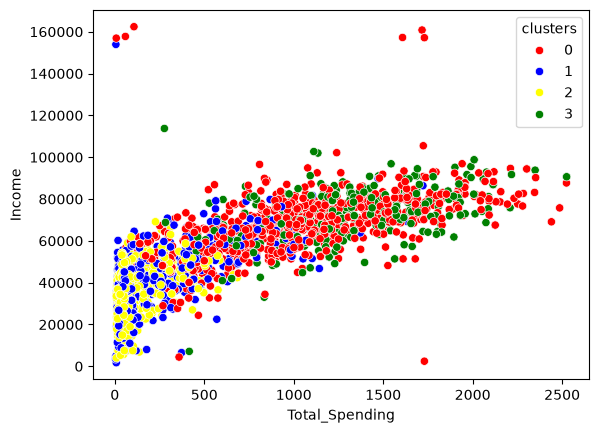

In [128]:
# Income - spending patterns
sns.scatterplot(x=X["Total_Spending"], y=X["Income"], hue=X["clusters"], palette=pal)

In [130]:
# Cluster Summary
cluster_summary = X.groupby("clusters").mean()
print(cluster_summary)

                Income    Recency  MntFruits  NumDealsPurchases  \
clusters                                                          
0         67167.792810  48.884967  43.250980           2.535948   
1         40743.733663  48.138614   8.877228           2.544554   
2         34599.378877  49.214180   5.454948           2.171344   
3         71914.596886  51.207612  60.519031           1.750865   

          NumWebPurchases  NumCatalogPurchases  NumStorePurchases  \
clusters                                                            
0                5.653595             4.499346           7.968627   
1                3.148515             1.160396           4.099010   
2                2.314623             0.548006           3.366322   
3                5.737024             5.384083           8.698962   

          NumWebVisitsMonth  Complain  Response        Age  \
clusters                                                     
0                  4.194771  0.006536  0.145098  59.690196